# Experiment 4: Binary Classification (Logistic Regression vs SVM)

Spambase again, this time Logistic Regression vs SVM with different kernels.

In [1]:
%matplotlib inline

In [2]:
import warnings
warnings.filterwarnings("ignore")
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      cross_val_score, GridSearchCV, RandomizedSearchCV)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay)

RNG = 42
sns.set_style("whitegrid")

## Plot styling

In [3]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 15
plt.rcParams['legend.fontsize'] = 15
plt.rcParams['legend.title_fontsize'] = 15
plt.rcParams['axes.labelweight'] = 'bold'

## Load the data

In [4]:
WORDS = ["make","address","all","3d","our","over","remove","internet","order","mail",
"receive","will","people","report","addresses","free","business","email","you","credit",
"your","font","000","money","hp","hpl","george","650","lab","labs","telnet","857","data",
"415","85","technology","1999","parts","pm","direct","cs","meeting","original","project",
"re","edu","table","conference"]
CHARS = [";","(","[","!","$","#"]
COL_NAMES = ([f"word_freq_{w}" for w in WORDS] + [f"char_freq_{c}" for c in CHARS] +
             ["capital_run_length_average","capital_run_length_longest",
              "capital_run_length_total","is_spam"])

df = pd.read_csv("spambase.data", header=None, names=COL_NAMES)
print("Dataset shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Class distribution:\n", df["is_spam"].value_counts())

X = df.drop(columns=["is_spam"]).values
y = df["is_spam"].values

Dataset shape: (4601, 58)
Missing values: 0
Class distribution:
 is_spam
0    2788
1    1813
Name: count, dtype: int64


## EDA

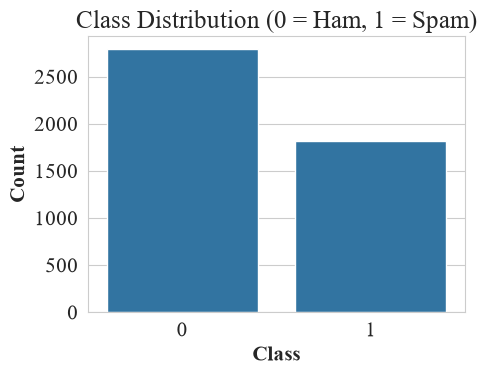

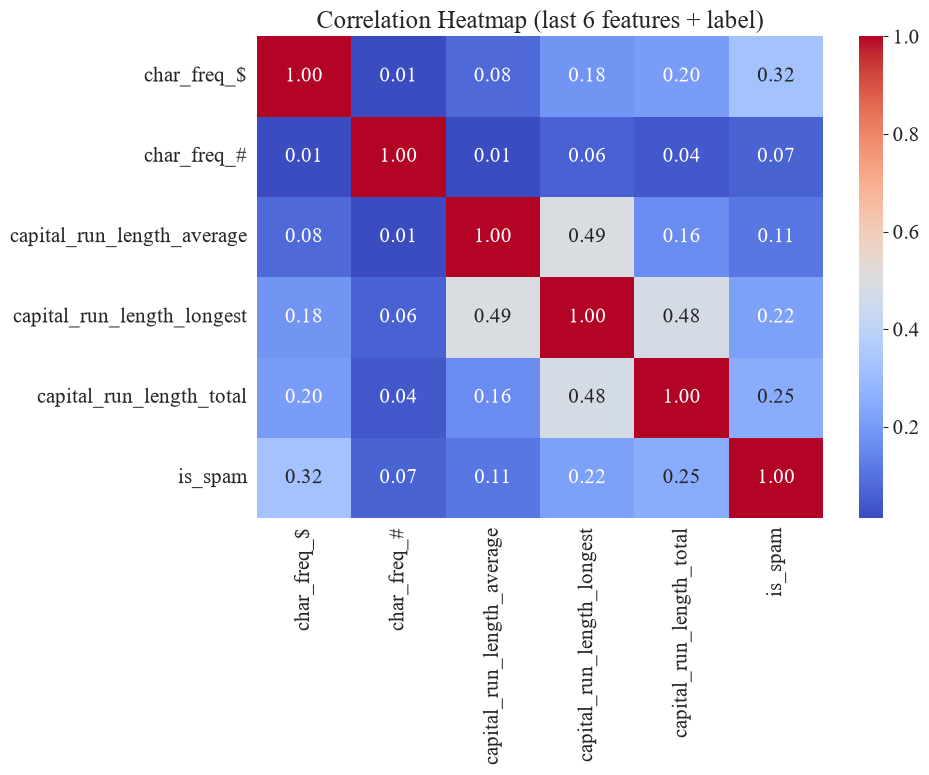

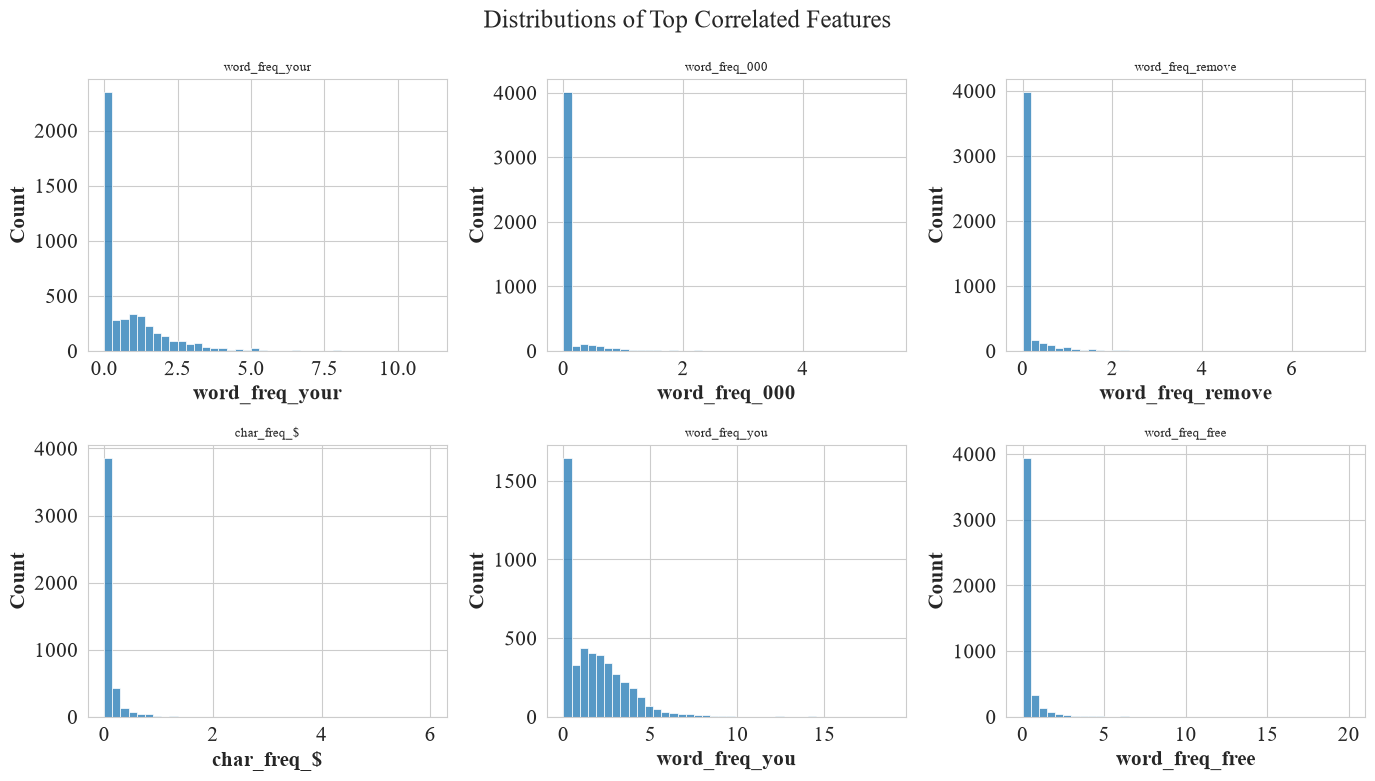

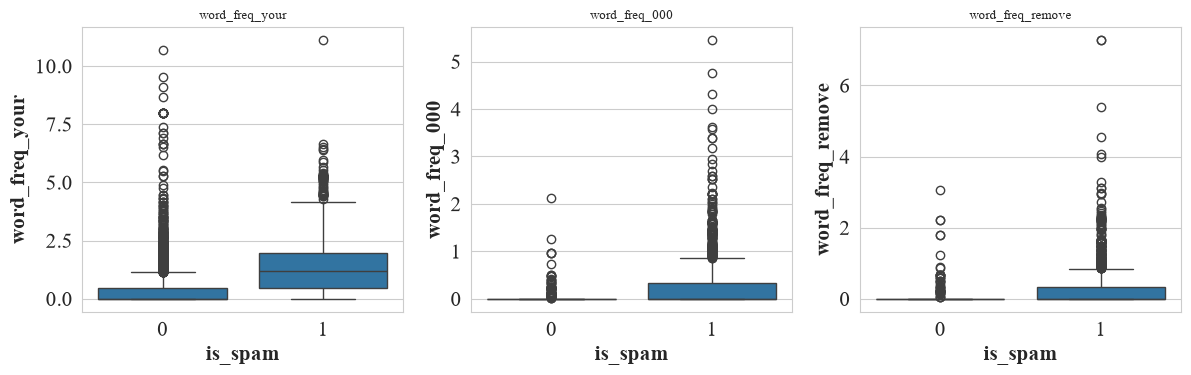

In [5]:
plt.figure(figsize=(5,4))
sns.countplot(x=y)
plt.title("Class Distribution (0 = Ham, 1 = Spam)")
plt.xlabel("Class"); plt.ylabel("Count")
plt.tight_layout(); plt.savefig("figures/01_class_distribution.png", dpi=150); plt.show()
plt.close()

plt.figure(figsize=(10,8))
corr = df.corr()
sns.heatmap(corr.iloc[-6:,-6:], annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap (last 6 features + label)")
plt.tight_layout(); plt.savefig("figures/02_correlation_heatmap.png", dpi=150); plt.show()
plt.close()

top_feats = corr["is_spam"].drop("is_spam").abs().sort_values(ascending=False).head(6).index.tolist()
fig, axes = plt.subplots(2,3, figsize=(14,8))
for ax, feat in zip(axes.ravel(), top_feats):
    sns.histplot(df[feat], bins=40, ax=ax, kde=False)
    ax.set_title(feat, fontsize=9)
plt.suptitle("Distributions of Top Correlated Features")
plt.tight_layout(); plt.savefig("figures/03_histograms.png", dpi=150); plt.show()
plt.close()

fig, axes = plt.subplots(1,3, figsize=(12,4))
for ax, feat in zip(axes.ravel(), top_feats[:3]):
    sns.boxplot(x=y, y=df[feat], ax=ax)
    ax.set_title(feat, fontsize=9); ax.set_xlabel("is_spam")
plt.tight_layout(); plt.savefig("figures/04_boxplots.png", dpi=150); plt.show()
plt.close()

## EDA summary figure

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


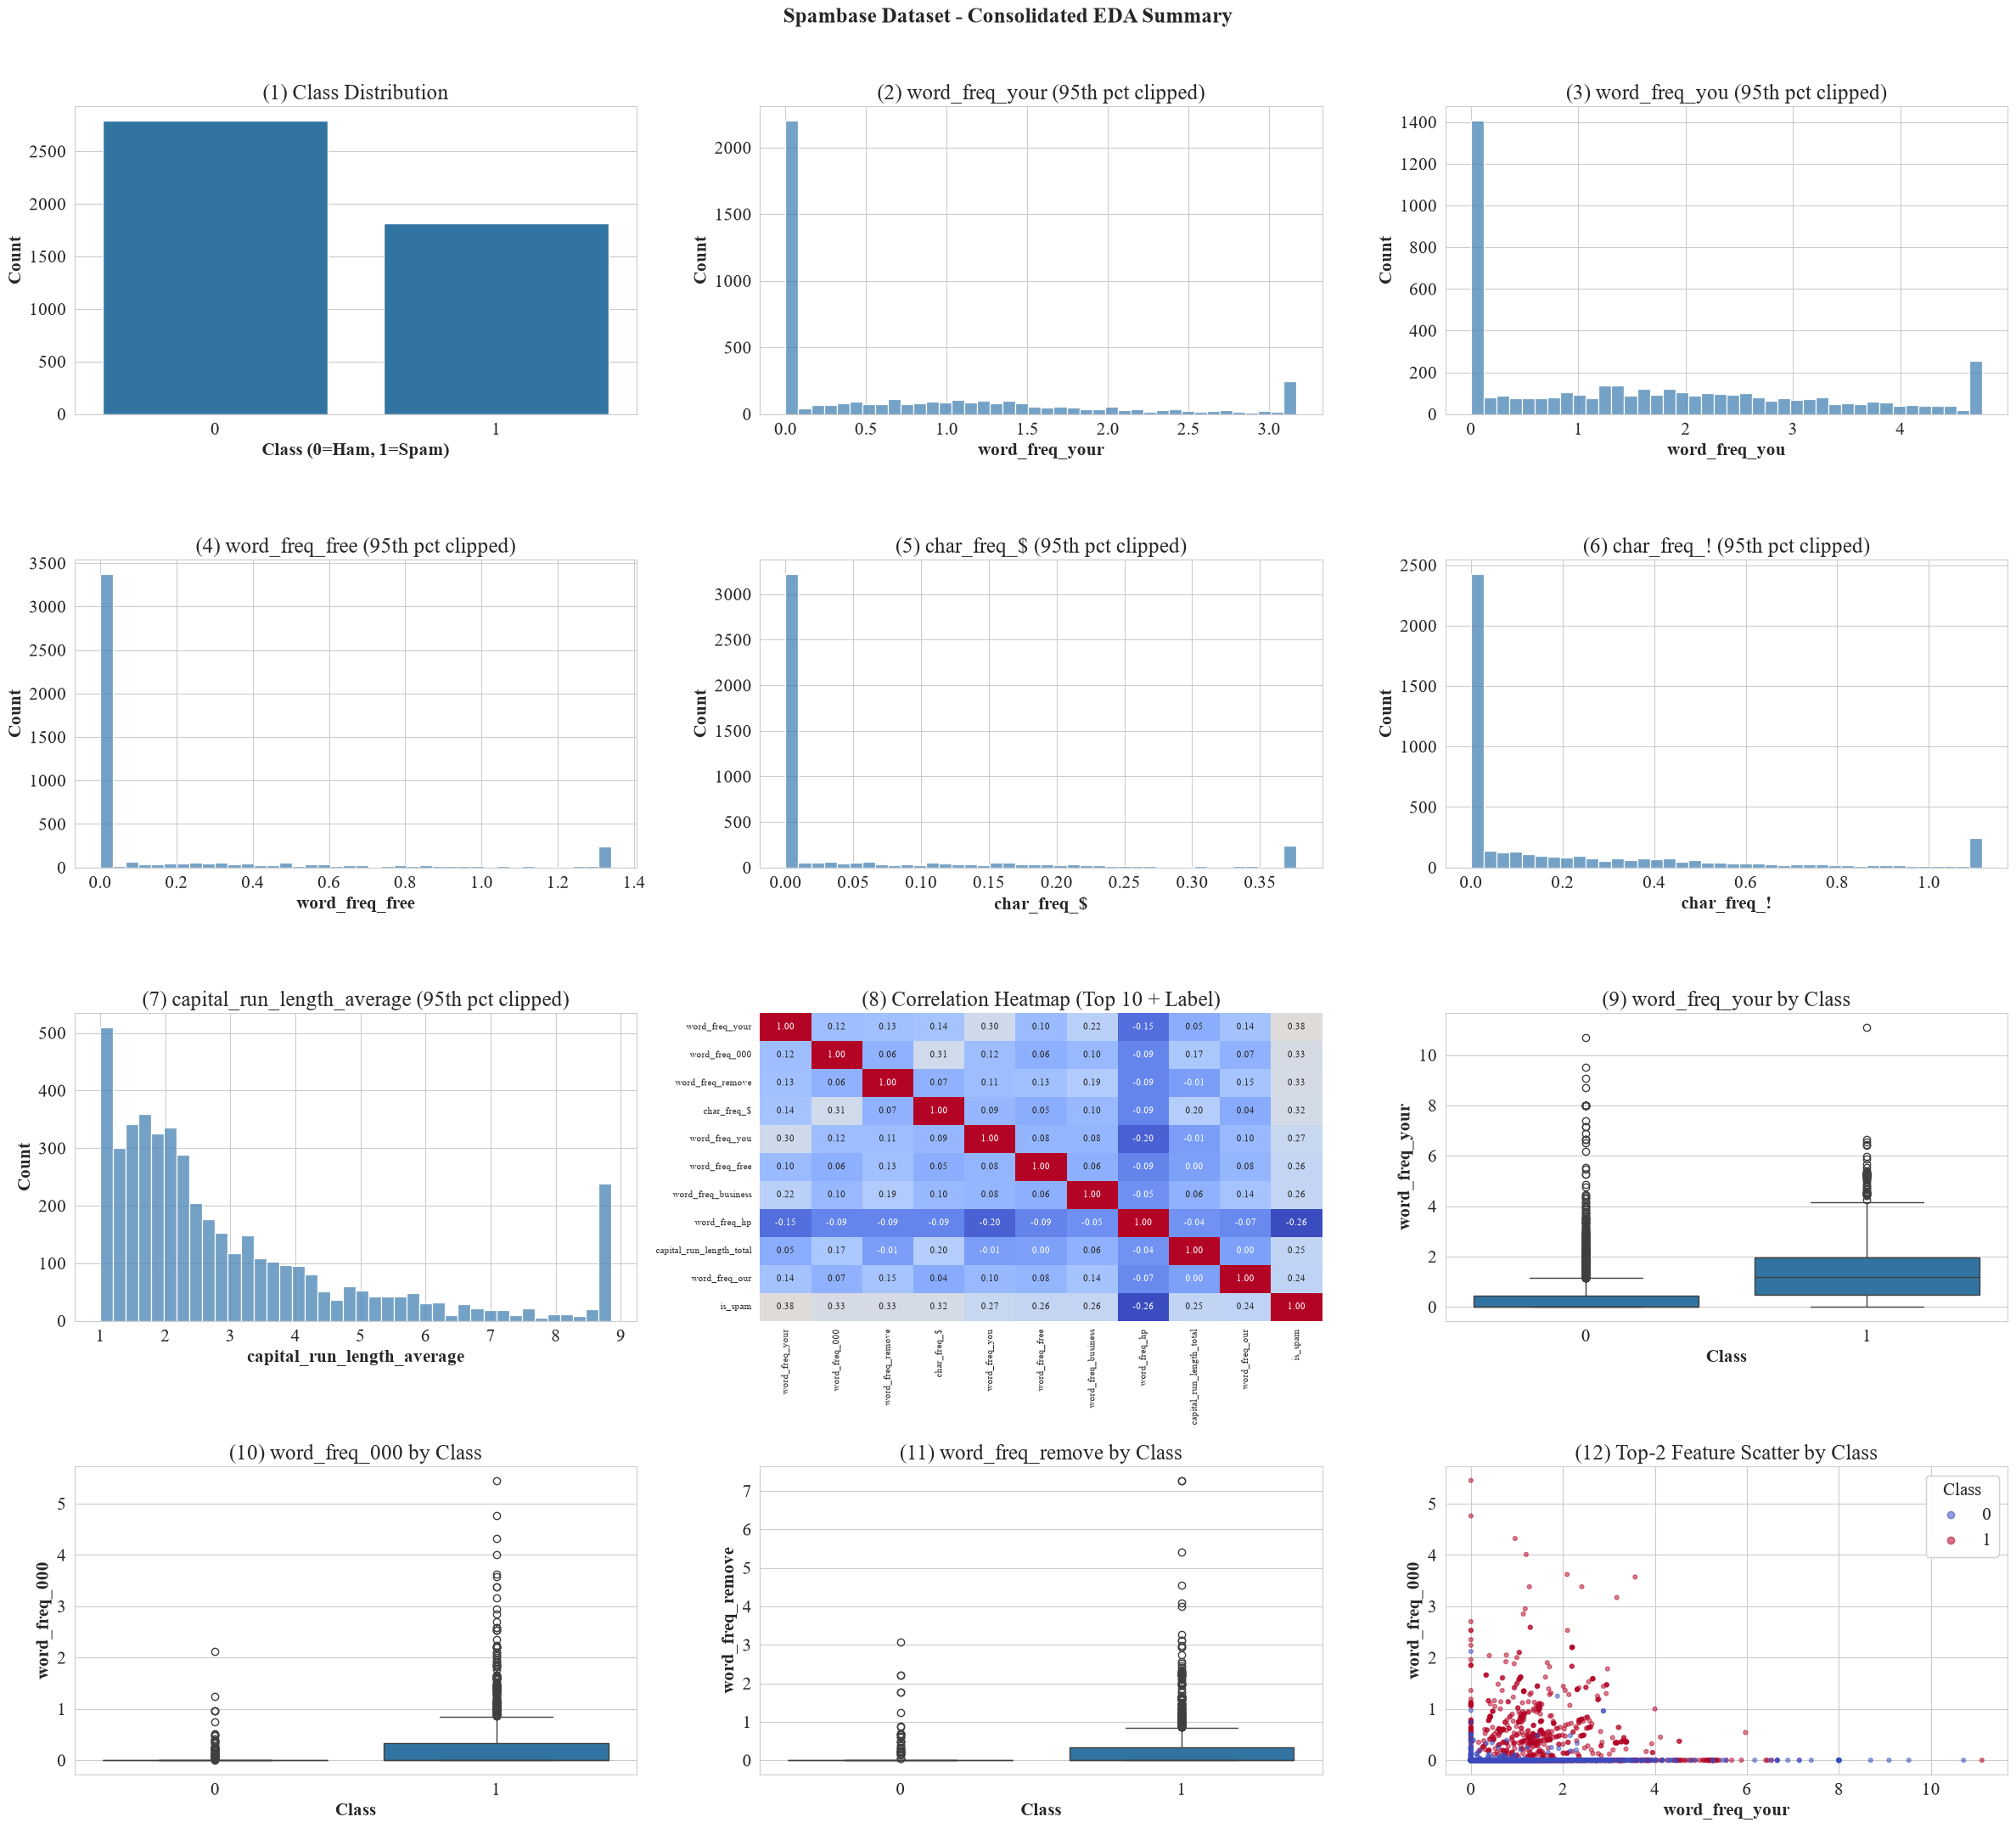

In [6]:
def build_eda_summary_figure(df, top_feats):
    hist_feats = ["word_freq_your", "word_freq_you", "word_freq_free",
                  "char_freq_$", "char_freq_!", "capital_run_length_average"]

    fig, axes = plt.subplots(4, 3, figsize=(24, 22))
    axes_flat = axes.ravel()

    ax = axes_flat[0]
    sns.countplot(x=df["is_spam"], ax=ax)
    ax.set_title("(1) Class Distribution")
    ax.set_xlabel("Class (0=Ham, 1=Spam)"); ax.set_ylabel("Count")

    for i, feat in enumerate(hist_feats):
        ax = axes_flat[1 + i]
        clip_val = df[feat].quantile(0.95)
        clipped = df[feat].clip(upper=clip_val)
        sns.histplot(clipped, bins=40, ax=ax, kde=False, color="steelblue")
        ax.set_title(f"({2+i}) {feat} (95th pct clipped)")
        ax.set_xlabel(feat); ax.set_ylabel("Count")

    ax = axes_flat[7]
    heat_cols = top_feats + ["is_spam"]
    heat_corr = df[heat_cols].corr()
    sns.heatmap(heat_corr, annot=True, fmt=".2f", cmap="coolwarm",
                ax=ax, annot_kws={"size": 8}, cbar=False)
    ax.set_title("(8) Correlation Heatmap (Top 10 + Label)")
    ax.tick_params(axis='x', rotation=90, labelsize=8)
    ax.tick_params(axis='y', rotation=0, labelsize=8)

    for i, feat in enumerate(top_feats[:3]):
        ax = axes_flat[8 + i]
        sns.boxplot(x=df["is_spam"], y=df[feat], ax=ax)
        ax.set_title(f"({9+i}) {feat} by Class")
        ax.set_xlabel("Class"); ax.set_ylabel(feat)

    ax = axes_flat[11]
    feat_x, feat_y = top_feats[0], top_feats[1]
    scatter = ax.scatter(df[feat_x], df[feat_y], c=df["is_spam"],
                          cmap="coolwarm", alpha=0.5, s=12)
    ax.set_title("(12) Top-2 Feature Scatter by Class")
    ax.set_xlabel(feat_x); ax.set_ylabel(feat_y)
    legend1 = ax.legend(*scatter.legend_elements(), title="Class", loc="upper right")
    ax.add_artist(legend1)

    fig.suptitle("Spambase Dataset - Consolidated EDA Summary", fontsize=18, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    return fig

top10_feats = corr["is_spam"].drop("is_spam").abs().sort_values(ascending=False).head(10).index.tolist()

eda_fig = build_eda_summary_figure(df, top10_feats)
eda_fig.savefig("figures/00_eda_summary.eps", format="eps", dpi=600)
eda_fig.savefig("figures/00_eda_summary.png", dpi=150)
plt.show()
plt.close(eda_fig)

## Preprocessing

In [7]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RNG)

scaler = StandardScaler().fit(X_train_raw)
X_train = scaler.transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

def evaluate(y_true, y_pred, y_score=None):
    d = dict(accuracy=accuracy_score(y_true, y_pred),
             precision=precision_score(y_true, y_pred),
             recall=recall_score(y_true, y_pred),
             f1=f1_score(y_true, y_pred))
    if y_score is not None:
        d["roc_auc"] = roc_auc_score(y_true, y_score)
    return d

## Helper functions

In [8]:
def train_and_evaluate_classifier(model, X_train, y_train, X_test, y_test):
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    fit_time = time.perf_counter() - t0

    t0 = time.perf_counter()
    y_pred = model.predict(X_test)
    predict_time = time.perf_counter() - t0

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
    else:
        y_score = None

    metrics = evaluate(y_test, y_pred, y_score)
    return {
        "model": model,
        "y_pred": y_pred,
        "y_score": y_score,
        "metrics": metrics,
        "fit_time": fit_time,
        "predict_time": predict_time,
    }

def evaluate_fitted_classifier(model, X_test, y_test):
    t0 = time.perf_counter()
    y_pred = model.predict(X_test)
    predict_time = time.perf_counter() - t0

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
    else:
        y_score = None

    metrics = evaluate(y_test, y_pred, y_score)
    return {"y_pred": y_pred, "y_score": y_score, "metrics": metrics, "predict_time": predict_time}

## Baseline logistic regression

In [9]:
lr_base_result = train_and_evaluate_classifier(
    LogisticRegression(max_iter=2000, random_state=RNG), X_train, y_train, X_test, y_test)
lr_base = lr_base_result["model"]
lr_base_time = lr_base_result["fit_time"]
lr_base_pred = lr_base_result["y_pred"]
lr_base_score = lr_base_result["y_score"]
lr_base_metrics = lr_base_result["metrics"]
print("Baseline Logistic Regression:", lr_base_metrics)

Baseline Logistic Regression: {'accuracy': 0.9294245385450597, 'precision': 0.9209039548022598, 'recall': 0.8980716253443526, 'f1': 0.9093444909344491, 'roc_auc': 0.9701956021604116}


## Logistic regression tuning

In [10]:
lr_param_grid = [
    {"penalty":["l1"], "C":[0.01,0.1,1,10,100], "solver":["liblinear","saga"]},
    {"penalty":["l2"], "C":[0.01,0.1,1,10,100], "solver":["liblinear","saga"]},
]
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)

t0 = time.perf_counter()
lr_grid = GridSearchCV(LogisticRegression(max_iter=2000, random_state=RNG),
                        lr_param_grid, cv=cv5, scoring="accuracy", n_jobs=1)
lr_grid.fit(X_train, y_train)
lr_grid_time = time.perf_counter() - t0
print("LR GridSearch best:", lr_grid.best_params_, lr_grid.best_score_, f"{lr_grid_time:.2f}s")

lr_param_dist = {"penalty":["l1","l2"], "C":[0.01,0.1,1,10,100], "solver":["liblinear","saga"]}
t0 = time.perf_counter()
lr_rand = RandomizedSearchCV(LogisticRegression(max_iter=2000, random_state=RNG),
                              lr_param_dist, n_iter=10, cv=cv5, scoring="accuracy",
                              random_state=RNG, n_jobs=1)
lr_rand.fit(X_train, y_train)
lr_rand_time = time.perf_counter() - t0
print("LR RandomSearch best:", lr_rand.best_params_, lr_rand.best_score_, f"{lr_rand_time:.2f}s")

lr_best = lr_grid.best_estimator_ if lr_grid.best_score_ >= lr_rand.best_score_ else lr_rand.best_estimator_
lr_best_result = evaluate_fitted_classifier(lr_best, X_test, y_test)
lr_best_pred = lr_best_result["y_pred"]
lr_best_score = lr_best_result["y_score"]
lr_best_metrics = lr_best_result["metrics"]
print("Tuned Logistic Regression (test):", lr_best_metrics)

LR GridSearch best: {'C': 100, 'penalty': 'l1', 'solver': 'liblinear'} 0.9260869565217392 54.41s


LR RandomSearch best: {'solver': 'liblinear', 'penalty': 'l1', 'C': 100} 0.9260869565217392 26.24s
Tuned Logistic Regression (test): {'accuracy': 0.9261672095548317, 'precision': 0.9202279202279202, 'recall': 0.8898071625344353, 'f1': 0.9047619047619048, 'roc_auc': 0.967860422405877}


## SVM kernels

In [11]:
svm_kernel_results = {}
for kernel in ["linear","poly","rbf","sigmoid"]:
    res = train_and_evaluate_classifier(
        SVC(kernel=kernel, probability=True, random_state=RNG), X_train, y_train, X_test, y_test)
    m = dict(res["metrics"])
    m["train_time"] = res["fit_time"]
    m["predict_time"] = res["predict_time"]
    svm_kernel_results[kernel] = m
    print(f"SVM ({kernel}):", m)

SVM (linear): {'accuracy': 0.9294245385450597, 'precision': 0.9209039548022598, 'recall': 0.8980716253443526, 'f1': 0.9093444909344491, 'roc_auc': 0.9694846806283757, 'train_time': 0.8733930000162218, 'predict_time': 0.00987639999948442}


SVM (poly): {'accuracy': 0.7795874049945711, 'precision': 0.9597701149425287, 'recall': 0.46005509641873277, 'f1': 0.6219739292364991, 'roc_auc': 0.9554711336236263, 'train_time': 0.7524888000043575, 'predict_time': 0.022829199995612726}


SVM (rbf): {'accuracy': 0.9272529858849077, 'precision': 0.9277456647398844, 'recall': 0.8842975206611571, 'f1': 0.9055007052186178, 'roc_auc': 0.9666854270959843, 'train_time': 0.5472294999926817, 'predict_time': 0.04423369999858551}


SVM (sigmoid): {'accuracy': 0.8849077090119435, 'precision': 0.8599439775910365, 'recall': 0.8457300275482094, 'f1': 0.8527777777777777, 'roc_auc': 0.9386459906987766, 'train_time': 0.47360609998577274, 'predict_time': 0.01704760000575334}


## SVM tuning

In [12]:
svm_param_grid = {"C":[0.1,1,10,100], "gamma":["scale","auto"], "kernel":["rbf"]}
t0 = time.perf_counter()
svm_grid = GridSearchCV(SVC(probability=True, random_state=RNG), svm_param_grid,
                         cv=cv5, scoring="accuracy", n_jobs=1)
svm_grid.fit(X_train, y_train)
svm_grid_time = time.perf_counter() - t0
print("SVM GridSearch best:", svm_grid.best_params_, svm_grid.best_score_, f"{svm_grid_time:.2f}s")

svm_param_dist = {"C":[0.1,1,10,100], "gamma":["scale","auto"], "kernel":["rbf","poly","sigmoid"]}
t0 = time.perf_counter()
svm_rand = RandomizedSearchCV(SVC(probability=True, random_state=RNG), svm_param_dist,
                               n_iter=10, cv=cv5, scoring="accuracy", random_state=RNG, n_jobs=1)
svm_rand.fit(X_train, y_train)
svm_rand_time = time.perf_counter() - t0
print("SVM RandomSearch best:", svm_rand.best_params_, svm_rand.best_score_, f"{svm_rand_time:.2f}s")

svm_best = svm_grid.best_estimator_ if svm_grid.best_score_ >= svm_rand.best_score_ else svm_rand.best_estimator_
svm_best_result = evaluate_fitted_classifier(svm_best, X_test, y_test)
svm_best_pred = svm_best_result["y_pred"]
svm_best_score = svm_best_result["y_score"]
svm_best_metrics = svm_best_result["metrics"]
print("Tuned SVM (test):", svm_best_metrics)

SVM GridSearch best: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'} 0.9355978260869564 18.10s


SVM RandomSearch best: {'kernel': 'rbf', 'gamma': 'auto', 'C': 1} 0.9320652173913043 21.96s
Tuned SVM (test): {'accuracy': 0.9207383279044516, 'precision': 0.9142857142857143, 'recall': 0.8815426997245179, 'f1': 0.8976157082748948, 'roc_auc': 0.9701807912951609}


## 5-fold CV comparison

In [13]:
lr_cv_scores = cross_val_score(lr_best, X_train, y_train, cv=cv5, scoring="accuracy")
svm_cv_scores = cross_val_score(svm_best, X_train, y_train, cv=cv5, scoring="accuracy")
print("LR CV folds:", lr_cv_scores, "mean:", lr_cv_scores.mean())
print("SVM CV folds:", svm_cv_scores, "mean:", svm_cv_scores.mean())

LR CV folds: [0.94157609 0.92527174 0.93478261 0.91168478 0.91711957] mean: 0.9260869565217392
SVM CV folds: [0.94429348 0.94157609 0.93478261 0.93070652 0.92663043] mean: 0.9355978260869564


## Plots

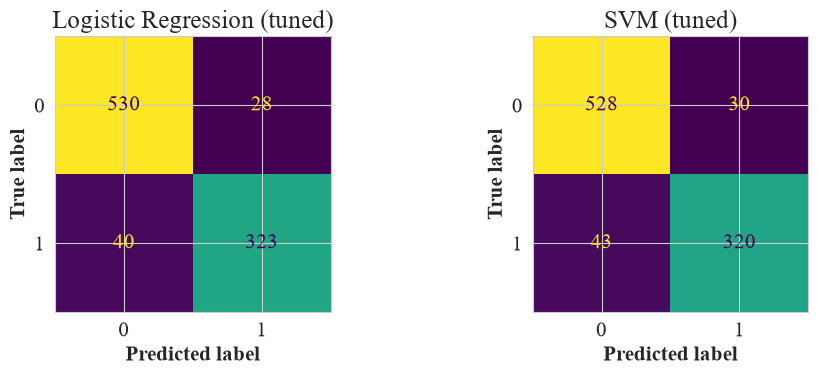

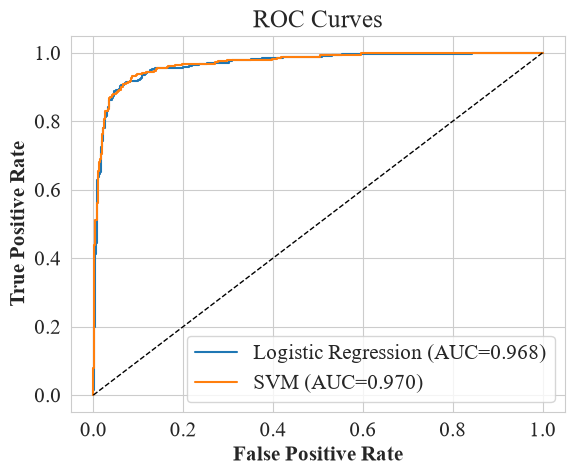

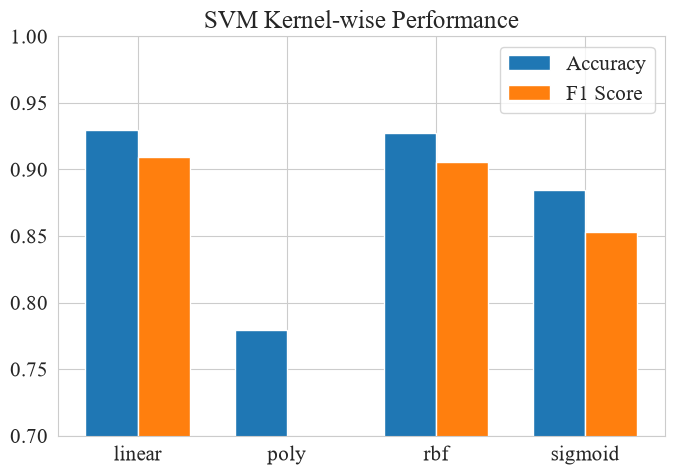

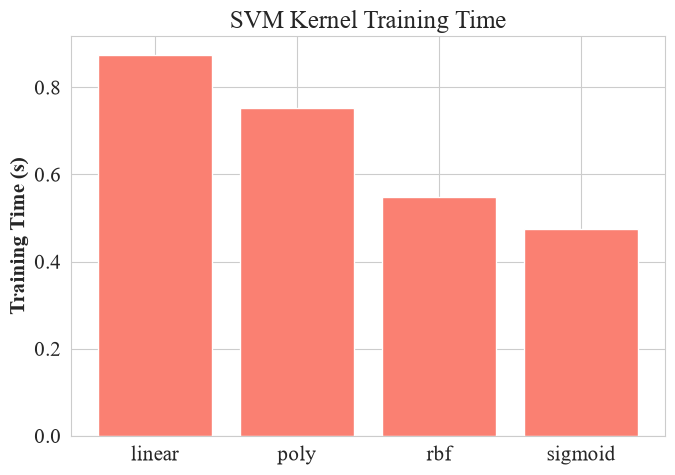

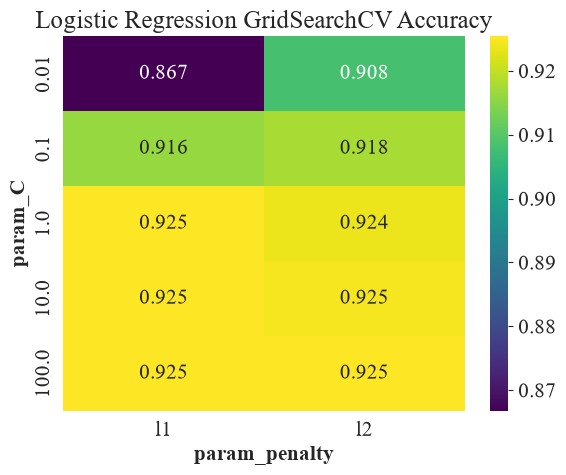

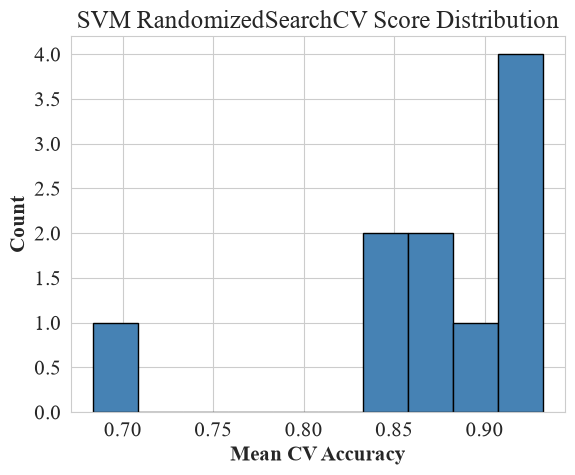

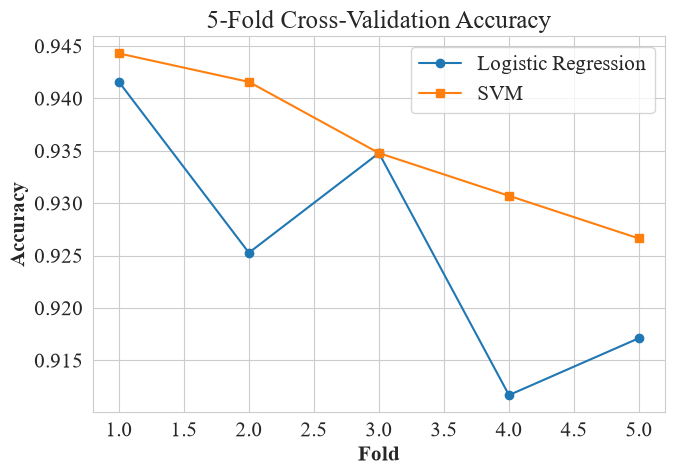

In [14]:
fig, axes = plt.subplots(1,2, figsize=(10,4))
ConfusionMatrixDisplay(confusion_matrix(y_test, lr_best_pred)).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Logistic Regression (tuned)")
ConfusionMatrixDisplay(confusion_matrix(y_test, svm_best_pred)).plot(ax=axes[1], colorbar=False)
axes[1].set_title("SVM (tuned)")
plt.tight_layout(); plt.savefig("figures/05_confusion_matrices.png", dpi=150); plt.show()
plt.close()

plt.figure(figsize=(6,5))
for name, score in [("Logistic Regression", lr_best_score), ("SVM", svm_best_score)]:
    fpr, tpr, _ = roc_curve(y_test, score)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test,score):.3f})")
plt.plot([0,1],[0,1],"k--", lw=1)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves"); plt.legend()
plt.tight_layout(); plt.savefig("figures/06_roc_curves.png", dpi=150); plt.show()
plt.close()

plt.figure(figsize=(7,5))
kernels = list(svm_kernel_results.keys())
accs = [svm_kernel_results[k]["accuracy"] for k in kernels]
f1s  = [svm_kernel_results[k]["f1"] for k in kernels]
x = np.arange(len(kernels)); w = 0.35
plt.bar(x-w/2, accs, width=w, label="Accuracy")
plt.bar(x+w/2, f1s, width=w, label="F1 Score")
plt.xticks(x, kernels); plt.ylim(0.7,1.0)
plt.title("SVM Kernel-wise Performance"); plt.legend()
plt.tight_layout(); plt.savefig("figures/07_svm_kernel_comparison.png", dpi=150); plt.show()
plt.close()

plt.figure(figsize=(7,5))
times = [svm_kernel_results[k]["train_time"] for k in kernels]
plt.bar(kernels, times, color="salmon")
plt.ylabel("Training Time (s)"); plt.title("SVM Kernel Training Time")
plt.tight_layout(); plt.savefig("figures/08_svm_training_time.png", dpi=150); plt.show()
plt.close()

res = pd.DataFrame(lr_grid.cv_results_)
pivot = res.pivot_table(values="mean_test_score", index="param_C", columns="param_penalty")
plt.figure(figsize=(6,5))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis")
plt.title("Logistic Regression GridSearchCV Accuracy")
plt.tight_layout(); plt.savefig("figures/09_lr_gridsearch_heatmap.png", dpi=150); plt.show()
plt.close()

plt.figure(figsize=(6,5))
plt.hist(svm_rand.cv_results_["mean_test_score"], bins=10, color="steelblue", edgecolor="k")
plt.xlabel("Mean CV Accuracy"); plt.ylabel("Count")
plt.title("SVM RandomizedSearchCV Score Distribution")
plt.tight_layout(); plt.savefig("figures/10_svm_randomsearch_distribution.png", dpi=150); plt.show()
plt.close()

plt.figure(figsize=(7,5))
folds = np.arange(1,6)
plt.plot(folds, lr_cv_scores, marker="o", label="Logistic Regression")
plt.plot(folds, svm_cv_scores, marker="s", label="SVM")
plt.xlabel("Fold"); plt.ylabel("Accuracy"); plt.title("5-Fold Cross-Validation Accuracy")
plt.legend(); plt.tight_layout(); plt.savefig("figures/11_cv_fold_comparison.png", dpi=150); plt.show()
plt.close()

## Save results

In [15]:
with open("results_summary.txt","w") as f:
    f.write(f"Dataset shape: {df.shape}\n")
    f.write(f"Class distribution: {df['is_spam'].value_counts().to_dict()}\n\n")

    f.write(f"LR GridSearch best params: {lr_grid.best_params_}\n")
    f.write(f"LR GridSearch best CV acc: {lr_grid.best_score_:.4f}  time={lr_grid_time:.2f}s\n")
    f.write(f"LR RandomSearch best params: {lr_rand.best_params_}\n")
    f.write(f"LR RandomSearch best CV acc: {lr_rand.best_score_:.4f}  time={lr_rand_time:.2f}s\n\n")

    f.write(f"SVM GridSearch best params: {svm_grid.best_params_}\n")
    f.write(f"SVM GridSearch best CV acc: {svm_grid.best_score_:.4f}  time={svm_grid_time:.2f}s\n")
    f.write(f"SVM RandomSearch best params: {svm_rand.best_params_}\n")
    f.write(f"SVM RandomSearch best CV acc: {svm_rand.best_score_:.4f}  time={svm_rand_time:.2f}s\n\n")

    f.write(f"Baseline LR test metrics: {lr_base_metrics}  train_time={lr_base_time:.4f}s\n")
    f.write(f"Tuned LR test metrics: {lr_best_metrics}\n\n")
    f.write(f"Tuned SVM test metrics: {svm_best_metrics}\n\n")

    for k in kernels:
        f.write(f"SVM[{k}] test metrics: {svm_kernel_results[k]}\n")
    f.write("\n")

    f.write(f"LR 5-fold CV scores: {lr_cv_scores.tolist()}  mean={lr_cv_scores.mean():.4f} std={lr_cv_scores.std():.4f}\n")
    f.write(f"SVM 5-fold CV scores: {svm_cv_scores.tolist()}  mean={svm_cv_scores.mean():.4f} std={svm_cv_scores.std():.4f}\n")

print("\nDone. Results written to results_summary.txt and figures/ directory.")


Done. Results written to results_summary.txt and figures/ directory.
